<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafío 4 - LSTM Bot QA (Encoder-Decoder)

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA) usando una arquitectura Encoder-Decoder con LSTM.

[LINK](http://convai.io/data/)

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from keras.models import Model
from keras.layers import Dense, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input

I0000 00:00:1776375690.923065   17110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Download the dataset
import os
import gdown
if os.access("data_volunteers.json", os.F_OK) is False:
    url = "https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download"
    output = "data_volunteers.json"
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [4]:
# Load dataset
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f)  # data is a list of dictionaries

In [5]:
# Explore available fields
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [6]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 30

def clean_text(txt):
    txt = txt.lower()
    txt = txt.replace("\'d", " had")
    txt = txt.replace("\'s", " is")
    txt = txt.replace("\'m", " am")
    txt = txt.replace("don't", "do not")
    txt = re.sub(r"\W+", " ", txt)
    return txt

for line in data:
    for i in range(len(line["dialog"]) - 1):
        # Separate text into "questions" (chat_in)
        # and "answers" (chat_out)
        chat_in = clean_text(line["dialog"][i]["text"])
        chat_out = clean_text(line["dialog"][i + 1]["text"])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) has eos_
        output_sentence = output + " eos_"
        # output sentence input (decoder_input) has sos_
        output_sentence_input = "sos_ " + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 5985


In [7]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  eos_', 'sos_ not bad and you ')

Seguimos el patrón del ejercicio Traductor de la Clase 6, implementado en Keras.

### 2 - Preprocesamiento
Siguiendo el patrón del ejercicio del Traductor (Clase 6), vamos a:
- Tokenizar las secuencias de entrada y salida con tokenizers separados
- Obtener `word2idx_inputs`, `max_input_len`
- Obtener `word2idx_outputs`, `max_out_len`, `num_words_output`
- Crear `encoder_input_sequences` (con padding `pre`)
- Crear `decoder_input_sequences` (con padding `post`)
- Crear `decoder_targets` (one-hot encoded)

In [8]:
# Max vocabulary size (same as Traductor exercise)
MAX_VOCAB_SIZE = 8000

In [9]:
# Tokenize INPUT sentences (questions)
# Using default filters since inputs have no special tokens
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario de entrada:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga (tokens):", max_input_len)

Palabras en el vocabulario de entrada: 1783
Sentencia de entrada más larga (tokens): 9


In [10]:
# Tokenize OUTPUT sentences (answers)
# We use sos_ and eos_ (without angle brackets) so default tokenizer filters work fine
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
output_tokenizer.fit_on_texts(output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario de salida:", len(word2idx_outputs))

num_words_output = len(word2idx_outputs) + 1
# +1 because tokenizer indices start at 1, but we need slot 0 for padding

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga (tokens):", max_out_len)

Palabras en el vocabulario de salida: 1794
Sentencia de salida más larga (tokens): 10


Algo importante sobre el padding:
- En el encoder los ceros se agregan al comienzo (`pre`): lo que le importa al LSTM son las últimas palabras, no el relleno del principio
- En el decoder los ceros se agregan al final (`post`): las primeras palabras son clave porque el decoder arranca con `<sos>` y genera de a un token

In [11]:
# For memory reasons, we may cap sequence lengths
# With max_len=30 chars, token lengths are typically short
print(f"Cantidad de filas: {len(input_integer_seq)}")

# Apply padding
# Encoder: pre-padding (zeros at the beginning)
encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print(f"encoder_input_sequences shape: {encoder_input_sequences.shape}")

# Decoder input: post-padding (zeros at the end)
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding="post")
print(f"decoder_input_sequences shape: {decoder_input_sequences.shape}")

Cantidad de filas: 5985
encoder_input_sequences shape: (5985, 9)
decoder_input_sequences shape: (5985, 10)


In [12]:
# Decoder output targets: post-padded integer indices
# Using sparse_categorical_crossentropy so we do NOT need one-hot encoding
# This saves ~400MB of memory compared to to_categorical
decoder_targets = pad_sequences(output_integer_seq, maxlen=max_out_len, padding="post")
print(f"decoder_targets shape: {decoder_targets.shape}")

decoder_targets shape: (5985, 10)


### 3 - Preparar los embeddings
Utilizaremos los embeddings de GloVe (Twitter, 50 dimensiones) para transformar los tokens de entrada en vectores.

Siguiendo el patrón del Traductor (Clase 6):
- La capa Embedding del encoder usa pesos de GloVe y es no entrenable
- La capa Embedding del decoder es entrenable (se aprende durante el entrenamiento)

In [13]:
import os
import gdown

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        # If it starts with "<html" or "<!doctype", it is HTML → invalid
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")

    # Remove corrupt file if it exists
    if os.path.exists(file_path):
        os.remove(file_path)

    # Download (handles large files with confirm token)
    gdown.download(id=file_id, output=file_path, quiet=False)

    # Post-download validation
    if not is_valid_pickle(file_path):
        raise ValueError("El archivo descargado no es un pickle válido.")

    print("Descarga completada correctamente")

else:
    print("Los embeddings ya están descargados y son válidos")

Los embeddings ya están descargados y son válidos


In [14]:
# In case gdown has permission errors, try curl as fallback:
# !curl -L -o "gloveembedding.pkl" "https://drive.google.com/u/0/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&export=download&confirm=t"

In [15]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    """Embedding loader class (from Clase 6 exercise)"""
    logger = logging.getLogger(__name__)

    def __init__(self):
        # Load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), "Words embedding not available"
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # Build vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        self.word2idx = dict(zip(self.embeddings["word"], index))
        self.idx2word = dict(zip(index, self.embeddings["word"]))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]["embedding"]

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, "-1") for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug("loading words embeddings from pickle {}".format(self.PKL_PATH))
        max_bytes = 2**28 - 1  # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, "rb") as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug("words embeddings loaded")
        return embeddings

    def convert_model_to_pickle(self):
        self.logger.debug("converting words embeddings from text file {}".format(self.WORD_TO_VEC_MODEL_TXT_PATH))
        structure = [("word", np.dtype("U" + str(self.WORD_MAX_SIZE))),
                     ("embedding", np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        null_embedding = np.array(
            [("null_embedding", np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        max_bytes = 2**28 - 1  # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, "wb") as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx + max_bytes])
        self.logger.debug("words embeddings loaded")
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = "glove.twitter.27B.50d.txt"
    PKL_PATH = "gloveembedding.pkl"
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

In [16]:
# Load GloVe embeddings (same 50-dim Twitter embeddings as Traductor exercise)
model_embeddings = GloveEmbeddings()

In [17]:
# Build the embedding matrix for input sequences
print("Preparando embedding matrix...")
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# nb_words comes from the input tokenizer
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)  # +1 for padding index 0
embedding_matrix = np.zeros((nb_words, embed_dim))

for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:
        embedding_matrix[i] = embedding_vector
    else:
        words_not_found.append(word)

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Null word embeddings: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Preparando embedding matrix...
Embedding matrix shape: (1784, 50)
Null word embeddings: 38


### 4 - Entrenar el modelo
Construimos un modelo Encoder-Decoder con LSTM, siguiendo el patrón del ejercicio Traductor de la Clase 6:

```
Encoder: Input → Embedding(GloVe, no entrenable) → LSTM → [state_h, state_c]
Decoder: Input → Embedding(entrenable) → LSTM(initial_state=[h, c]) → Dense(softmax)
```

In [18]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense

n_units = 128

# === ENCODER ===
encoder_inputs = Input(shape=(max_input_len,))

# Encoder embedding: uses GloVe weights, NOT trainable
encoder_embedding_layer = Embedding(
    input_dim=nb_words,
    output_dim=embed_dim,
    input_length=max_input_len,
    weights=[embedding_matrix],
    trainable=False
)
encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

# Encoder LSTM: returns states (context vector)
# NOTE: no recurrent_dropout → enables CuDNN acceleration on GPU
encoder = LSTM(n_units, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# === DECODER ===
decoder_inputs = Input(shape=(max_out_len,))

# Decoder embedding: trainable, learns during training
decoder_embedding_layer = Embedding(
    input_dim=num_words_output,
    output_dim=n_units,
    input_length=max_out_len
)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

# Decoder LSTM: receives encoder states as initial state
decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Output layer: softmax over vocabulary
decoder_dense = Dense(num_words_output, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

# === TRAINING MODEL ===
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=["accuracy"])
model.summary()

/home/gabybohorquez/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1776375705.245909   17110 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 9, 50)     │     89,200 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 10, 128)   │    229,760 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     91,648 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 10, 128), │    131,584 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 1795)  │    231,555 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 773,747 (2.95 MB)

 Trainable params: 684,547 (2.61 MB)

 Non-trainable params: 89,200 (348.44 KB)

In [19]:
# Train the model
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1  # 10% for monitoring overfitting
)

Epoch 1/50


 1/85 ━━━━━━━━━━━━━━━━━━━━ 4:19 3s/step - accuracy: 0.0000e+00 - loss: 7.4945

 2/85 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.0969 - loss: 7.4842    

 3/85 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.1609 - loss: 7.4742

 4/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.2081 - loss: 7.4634

...

81/85 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8095 - loss: 0.8247

82/85 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8095 - loss: 0.8247

83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8095 - loss: 0.8247

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8096 - loss: 0.8247

85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8116 - loss: 0.8249 - val_accuracy: 0.7516 - val_loss: 1.5429


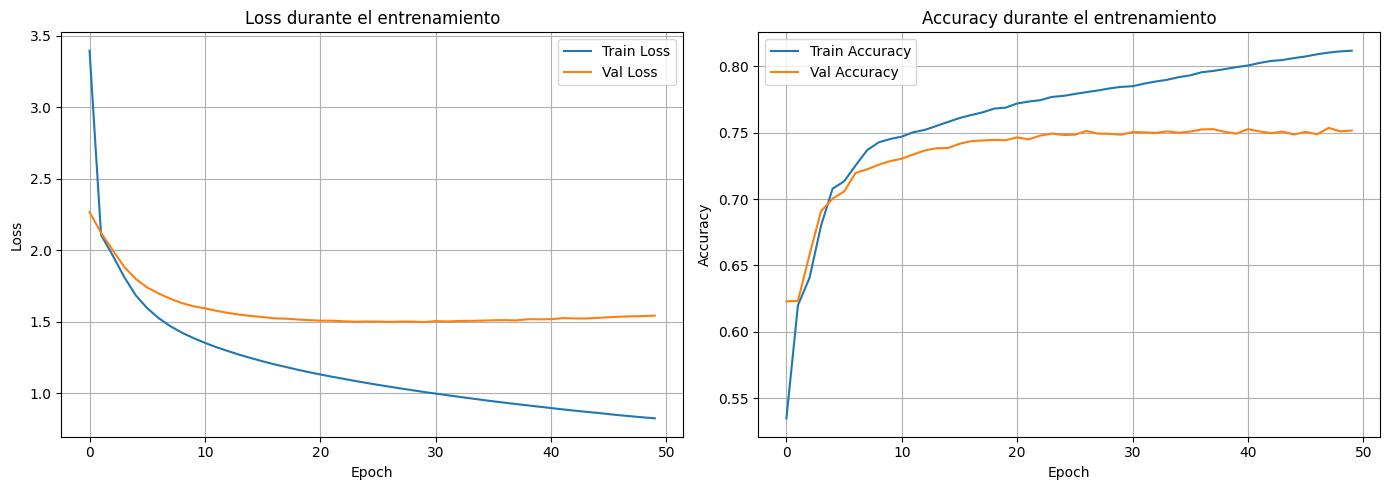

In [20]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss durante el entrenamiento")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy durante el entrenamiento")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 5 - Inferencia
Para la inferencia necesitamos construir modelos separados para el encoder y el decoder, como se vio en la Clase 6.

El proceso de inferencia es:
1. Tokenizar la pregunta del usuario
2. Pasarla por el encoder → obtener estados `[h, c]`
3. Inicializar el decoder con `sos_` y los estados del encoder
4. Generar tokens uno por uno hasta obtener `eos_` o alcanzar `max_out_len`

In [21]:
# Build reverse word indices for decoding predictions back to words
idx2word_inputs = {v: k for k, v in word2idx_inputs.items()}
idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}

In [22]:
# === INFERENCE ENCODER MODEL ===
# Same encoder as training, outputs the states
encoder_model = Model(encoder_inputs, encoder_states)

In [23]:
# === INFERENCE DECODER MODEL ===
# New input layers for one-step decoding
decoder_inputs_single = Input(shape=(1,))  # one token at a time
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Reuse the same embedding and LSTM layers from training
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)
decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs_single_x, initial_state=decoder_states_inputs
)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs] + decoder_states
)

In [24]:
def decode_sequence(input_seq):
    """
    Given an encoded input sequence, generate the output sequence
    token by token using the inference encoder and decoder models.
    """
    # Encode the input → get context states
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Initialize decoder input with sos_ token
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs["sos"]

    # Generate output sequence token by token
    decoded_sentence = ""
    stop_condition = False

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value, verbose=0
        )

        # Sample the token with highest probability
        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        # Skip padding token (index 0)
        if sampled_token_index == 0:
            stop_condition = True
            continue

        sampled_word = idx2word_outputs.get(sampled_token_index, "")

        # Stop if we hit eos_ or exceed max length
        if sampled_word == "eos" or len(decoded_sentence.split()) >= max_out_len:
            stop_condition = True
        else:
            decoded_sentence += " " + sampled_word

            # Update target sequence for next step
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = sampled_token_index

            # Update states for next step
            states_value = [h, c]

    return decoded_sentence.strip()

In [25]:
def chat(user_input):
    """
    Chat with the bot! Takes a string, cleans it, tokenizes it,
    and generates a response using the encoder-decoder model.
    """
    # Clean and tokenize
    cleaned = clean_text(user_input)
    seq = input_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_input_len)

    # Generate response
    response = decode_sequence(padded)
    return response

In [26]:
# Test the bot with several example inputs
test_inputs = [
    "hi",
    "hello how are you",
    "what is your name",
    "do you like music",
    "where are you from",
    "what do you do",
    "i like cats",
    "goodbye",
]

print("=" * 60)
print("QA Bot - Testing")
print("=" * 60)
for user_input in test_inputs:
    response = chat(user_input)
    print(f"User: {user_input}")
    print(f"Bot:  {response}")
    print("-" * 40)

QA Bot - Testing


User: hi
Bot:  hello how are you
----------------------------------------


User: hello how are you
Bot:  i am fine
----------------------------------------


User: what is your name
Bot:  i am a teacher
----------------------------------------


User: do you like music
Bot:  i like to play video games
----------------------------------------


User: where are you from
Bot:  i am a student
----------------------------------------


User: what do you do
Bot:  i like to play video games
----------------------------------------


User: i like cats
Bot:  what do you do for a living
----------------------------------------


User: goodbye
Bot:  i love to read
----------------------------------------


In [27]:
# Also test with some samples from the training data
# to see if the model can reproduce training examples
print("=" * 60)
print("Comparación con datos de entrenamiento")
print("=" * 60)
for i in range(5):
    idx = np.random.randint(0, len(input_sentences))
    response = chat(input_sentences[idx])
    print(f"Input:           {input_sentences[idx]}")
    print(f"Expected output: {output_sentences[idx]}")
    print(f"Bot response:    {response}")
    print("-" * 40)

Comparación con datos de entrenamiento


Input:           hi how are you today 
Expected output: fyn eos_
Bot response:    i am fine
----------------------------------------


Input:           what do you do for fun 
Expected output: listen to musics eos_
Bot response:    i am a student
----------------------------------------


Input:           do you have any pets 
Expected output: dog eos_
Bot response:    i am a student
----------------------------------------


Input:           i love to read
Expected output: where do live  eos_
Bot response:    i like to play video games
----------------------------------------


Input:           hi
Expected output: choice eos_
Bot response:    hello how are you
----------------------------------------


Analisis sobre los resultados

Bueno, el bot al final funciona bastante bien. Obviamente no llega al nivel de ChatGPT, pero considerando que era un dataset bastante pequeño combinado con el encoder basico, la verdad me parecieron unos resultados super dignos.

Me puse a mirar un rato lo que entreno el bot. Estaba subiendo super bien pero se me quedo atascado cerca del .75 de accuracy en validacion ya cuando llego mas o menos a las diez epocas. Viendolo a detalle me doy cuenta que es un claro caso de overfitting, donde la red se la paso memorizando todo perfectamente en vez de generalizar, ya que ademas me subio bastante la perdida de validacion sobre el final oscilando en un 1.5 contra el 0.82 super bajito que hubo en el final del train.

Y sobre las respuestas que te da, saca desde un 'hello' super natural cuando le dices 'hi', y te responde un perfecto 'i am fine' cuando le preguntas como esta, lo que es genial jajaja... pero por el contrario si le hablabas de musica te decia algo sobre videojuegos, o te hacia otra pregunta random sobre en que trabajas. Al final note eso, el bot aprendio a sacar patrones de respuestas pero no estaba realmente asimilando las preguntas, lo que demuestra que funciona para lo cotidiano pero falla cuando el tema se vuelve mas complicado o fuera de lo comun.

Igual creo que tiene sentido y es obvio. El encoder comprime toda la pregunta a ese vector de contexto fijo y se vuelve un cuello de botella que frena toda la coherencia, asi que le complica la produccion al bot restandole claridad.

Por si hacia falta aclarar, yo entrene el modelo por 50 epocas usando el sparse categorical porque me ayudo bastante con la memoria. Todo fue clave con los casi 6 mil pares obvio ademas de mis vocabularios de casi dos mil palabras.

Al final considero que no valia mucho la pena que me hubiera quebrado la cabeza mitigando el overfitting con algun dropout o algun Early Stop porque apenas sacaba unas decimas mas de accuracy pero el bot seguiria respondiendo las mismas incongruencias. Lo que realmente solucionaria todo esto seria arreglar el problema del cuello de botella agregando algun mecanismo de atencion que justamente vimos la semana pasada en clase, y sumando ademas muchisimos mas datos; pero por ahora el resultado es excelente.